# Service Desk Simulation — Week 6 Assignment

This notebook implements the assignment with a deliberately small SimPy model.

**Core idea**

1. Poisson arrivals determine **when** new tickets enter.
2. One complete historical row determines the ticket's **service times and route**.
3. SimPy technicians determine whether the ticket is **in service or waiting**.
4. Timestamps produce utilization, wait, throughput, queue, and system-time metrics.

The simulation clock contains staffed business minutes only:

- 480 minutes = one workday
- nights and weekends are omitted
- no separate lunch shutdown is modeled

This is an explicit simplifying assumption, not an accidental deletion of Earth’s rotation.

In [ ]:
# Packages

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import simpy

## 1. Parameters

In [28]:
DATA_FILE = Path("technical_support_tickets.xlsx")

RANDOM_SEED = 42
SIMULATION_DAYS = 20
WORK_MINUTES_PER_DAY = 480

# The professor specified Poisson arrivals but did not provide the rate.
AVERAGE_ARRIVALS_PER_DAY = 15

TECHNICIANS = {1: 3, 2: 2, 3: 1}
QUEUE_SAMPLE_INTERVAL = 5

## 2. Load the historical table

The table is **not** an arrival schedule. It is a library of realistic ticket profiles.

For each simulated arrival, we sample one full row. That row determines:

- service time at each visited level
- the final closing level
- therefore, the route through the system

In [29]:
df = pd.read_excel(DATA_FILE)

print(df.shape)
display(df.head())

routing_mix = (
    df["Closed_Level"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

display(routing_mix.rename("Percent"))

(500, 5)


,TicketID,Level1_Minutes,Level2_Minutes,Level3_Minutes,Closed_Level
0,TKT0446,20,91,0,2
1,TKT0199,106,0,0,1
2,TKT0379,91,0,0,1
3,TKT0094,115,39,39,3
4,TKT0283,82,6,62,3


Closed_Level
1    43.0
2    37.0
3    20.0
Name: Percent, dtype: float64

## 3. Define technicians and support stations

In [30]:
@dataclass
class Technician:
    technician_id: str
    level: int
    busy_minutes: float = 0.0


class SupportStation:
    def __init__(self, env, level, technician_count, event_log):
        self.env = env
        self.level = level
        self.event_log = event_log

        self.technicians = [
            Technician(
                technician_id=f"L{level}-Tech-{number}",
                level=level,
            )
            for number in range(1, technician_count + 1)
        ]

        self.available_technicians = simpy.Store(
            env,
            capacity=technician_count,
        )

        for technician in self.technicians:
            self.available_technicians.put(technician)

        self.wait_times = []
        self.queue_samples = []
        self.max_queue_length = 0


    def serve(self, simulated_ticket_id, service_minutes):
        queue_entry_time = self.env.now

        self.event_log.append({
            "SimTicketID": simulated_ticket_id,
            "Time": self.env.now,
            "Level": self.level,
            "State": f"Waiting for L{self.level}",
            "Technician": None,
        })

        # If no technician is free, the ticket pauses here in a FIFO queue.
        technician = yield self.available_technicians.get()

        service_start = self.env.now
        self.wait_times.append(service_start - queue_entry_time)

        self.event_log.append({
            "SimTicketID": simulated_ticket_id,
            "Time": self.env.now,
            "Level": self.level,
            "State": f"In service at L{self.level}",
            "Technician": technician.technician_id,
        })

        # The ticket is actively being worked on during this timeout.
        yield self.env.timeout(float(service_minutes))

        technician.busy_minutes += float(service_minutes)

        self.event_log.append({
            "SimTicketID": simulated_ticket_id,
            "Time": self.env.now,
            "Level": self.level,
            "State": f"Finished L{self.level}",
            "Technician": technician.technician_id,
        })

        # Return the technician to the free-technician pool.
        yield self.available_technicians.put(technician)

    def sample_queue(self):
        queue_length = len(self.available_technicians.get_queue)
        self.queue_samples.append(queue_length)
        self.max_queue_length = max(
            self.max_queue_length,
            queue_length,
        )

## 4. Define the simulation

In [31]:
class ServiceDeskSimulation:
    def __init__(self, ticket_data, seed=42):
        self.ticket_data = ticket_data.reset_index(drop=True)
        self.rng = np.random.default_rng(seed)
        self.env = simpy.Environment()

        self.event_log = []
        self.ticket_results = []

        self.stations = {
            level: SupportStation(
                self.env,
                level,
                TECHNICIANS[level],
                self.event_log,
            )
            for level in (1, 2, 3)
        }

        self.arrivals = 0
        self.completed = 0

    def sample_historical_ticket(self):
        row_number = self.rng.integers(0, len(self.ticket_data))
        return self.ticket_data.iloc[row_number]

    def process_ticket(self, simulated_ticket_id, row):
        arrival_time = self.env.now
        closed_level = int(row["Closed_Level"])

        self.event_log.append({
            "SimTicketID": simulated_ticket_id,
            "Time": self.env.now,
            "Level": None,
            "State": "Arrived",
            "Technician": None,
        })

        # All tickets visit L1.
        yield self.env.process(
            self.stations[1].serve(
                simulated_ticket_id,
                row["Level1_Minutes"],
            )
        )

        # Tickets closing at L2 or L3 visit L2.
        if closed_level >= 2:
            yield self.env.process(
                self.stations[2].serve(
                    simulated_ticket_id,
                    row["Level2_Minutes"],
                )
            )

        # Only tickets closing at L3 visit L3.
        if closed_level == 3:
            yield self.env.process(
                self.stations[3].serve(
                    simulated_ticket_id,
                    row["Level3_Minutes"],
                )
            )

        self.completed += 1
        completion_time = self.env.now

        self.event_log.append({
            "SimTicketID": simulated_ticket_id,
            "Time": self.env.now,
            "Level": None,
            "State": "Completed",
            "Technician": None,
        })

        self.ticket_results.append({
            "SimTicketID": simulated_ticket_id,
            "SampledHistoricalTicket": row["TicketID"],
            "ArrivalTime": arrival_time,
            "CompletionTime": completion_time,
            "TotalSystemTime": completion_time - arrival_time,
            "Closed_Level": closed_level,
            "Level1_Minutes": row["Level1_Minutes"],
            "Level2_Minutes": row["Level2_Minutes"],
            "Level3_Minutes": row["Level3_Minutes"],
        })

    def generate_arrivals(self, simulation_end):
        mean_interarrival = (
            WORK_MINUTES_PER_DAY / AVERAGE_ARRIVALS_PER_DAY
        )

        while True:
            interarrival = self.rng.exponential(mean_interarrival)
            next_arrival = self.env.now + interarrival

            if next_arrival >= simulation_end:
                break

            yield self.env.timeout(interarrival)

            self.arrivals += 1
            row = self.sample_historical_ticket()

            self.env.process(
                self.process_ticket(self.arrivals, row)
            )

    def monitor_queues(self, simulation_end):
        while self.env.now < simulation_end:
            for station in self.stations.values():
                station.sample_queue()

            yield self.env.timeout(QUEUE_SAMPLE_INTERVAL)

    def run(self):
        simulation_end = SIMULATION_DAYS * WORK_MINUTES_PER_DAY

        self.env.process(self.generate_arrivals(simulation_end))
        self.env.process(self.monitor_queues(simulation_end))
        self.env.run(until=simulation_end)

## 5. Run the model

In [32]:
model = ServiceDeskSimulation(df, seed=RANDOM_SEED)
model.run()

ticket_results = pd.DataFrame(model.ticket_results)
event_log = pd.DataFrame(model.event_log)

print(f"Arrivals:  {model.arrivals}")
print(f"Completed: {model.completed}")
print(f"Backlog:   {model.arrivals - model.completed}")

display(ticket_results.head())
display(event_log.head(20))

Arrivals:  296
Completed: 293
Backlog:   3


,SimTicketID,SampledHistoricalTicket,ArrivalTime,CompletionTime,TotalSystemTime,Closed_Level,Level1_Minutes,Level2_Minutes,Level3_Minutes
0,1,TKT0066,76.934675,136.934675,60.0,1,60,0,0
1,4,TKT0026,208.685581,230.685581,22.0,1,22,0,0
2,2,TKT0385,153.247027,299.247027,146.0,3,28,76,42
3,5,TKT0156,253.804323,353.804323,100.0,2,8,92,0
4,6,TKT0499,256.341738,420.341738,164.0,2,73,91,0


,SimTicketID,Time,Level,State,Technician
0,1,76.934675,NaN,Arrived,NaN
1,1,76.934675,1.0,Waiting for L1,NaN
2,1,76.934675,1.0,In service at L1,L1-Tech-1
3,1,136.934675,1.0,Finished L1,L1-Tech-1
4,1,136.934675,NaN,Completed,NaN
5,2,153.247027,NaN,Arrived,NaN
6,2,153.247027,1.0,Waiting for L1,NaN
7,2,153.247027,1.0,In service at L1,L1-Tech-2
8,3,162.200445,NaN,Arrived,NaN
9,3,162.200445,1.0,Waiting for L1,NaN


In [33]:
display(event_log.head(20))

,SimTicketID,Time,Level,State,Technician
0,1,76.934675,NaN,Arrived,NaN
1,1,76.934675,1.0,Waiting for L1,NaN
2,1,76.934675,1.0,In service at L1,L1-Tech-1
3,1,136.934675,1.0,Finished L1,L1-Tech-1
4,1,136.934675,NaN,Completed,NaN
5,2,153.247027,NaN,Arrived,NaN
6,2,153.247027,1.0,Waiting for L1,NaN
7,2,153.247027,1.0,In service at L1,L1-Tech-2
8,3,162.200445,NaN,Arrived,NaN
9,3,162.200445,1.0,Waiting for L1,NaN


## 6. Calculate metrics

In [37]:
total_available_minutes = (
    SIMULATION_DAYS * WORK_MINUTES_PER_DAY
)

technician_rows = []
station_rows = []

for level, station in model.stations.items():

    # Individual technician utilization
    for technician in station.technicians:
        busy = technician.busy_minutes

        technician_rows.append({
            "Level": level,
            "Technician": technician.technician_id,
            "BusyMinutes": busy,
            "UtilizationPercent": (
                100 * busy / total_available_minutes
            ),
        })

    # Total busy time across all technicians at this level
    station_busy = sum(
        technician.busy_minutes
        for technician in station.technicians
    )

    station_capacity = (
        total_available_minutes * len(station.technicians)
    )

    station_rows.append({
        "Level": level,
        "Technicians": len(station.technicians),
        "AverageUtilizationPercent": (
            100 * station_busy / station_capacity
        ),
        "AverageWaitMinutes": np.mean(station.wait_times),
        "MaximumWaitMinutes": np.max(station.wait_times),
        "AverageQueueLength": np.mean(station.queue_samples),
        "MaximumQueueLength": station.max_queue_length,
    })

technician_summary = pd.DataFrame(technician_rows)
station_summary = pd.DataFrame(station_rows)

overall_summary = pd.DataFrame([{
    "Arrivals": model.arrivals,
    "Completed": model.completed,
    "BacklogAtEnd": model.arrivals - model.completed,
    "CompletedPerDay": model.completed / SIMULATION_DAYS,
    "AverageSystemTimeMinutes": ticket_results["TotalSystemTime"].mean(),
    "MedianSystemTimeMinutes": ticket_results["TotalSystemTime"].median(),
}])

display(overall_summary.round(2))
display(station_summary.round(2))
display(technician_summary.round(2))

,Arrivals,Completed,BacklogAtEnd,CompletedPerDay,AverageSystemTimeMinutes,MedianSystemTimeMinutes
0,296,293,3,14.65,131.31,112.0


,Level,Technicians,AverageUtilizationPercent,AverageWaitMinutes,MaximumWaitMinutes,AverageQueueLength,MaximumQueueLength
0,1,3,63.32,12.17,102.25,0.38,5
1,2,2,52.36,21.23,157.11,0.34,5
2,3,1,28.49,15.69,121.53,0.08,3


,Level,Technician,BusyMinutes,UtilizationPercent
0,1,L1-Tech-1,5924.0,61.71
1,1,L1-Tech-2,6217.0,64.76
2,1,L1-Tech-3,6094.0,63.48
3,2,L2-Tech-1,5180.0,53.96
4,2,L2-Tech-2,4874.0,50.77
5,3,L3-Tech-1,2735.0,28.49


## 7. Basic charts

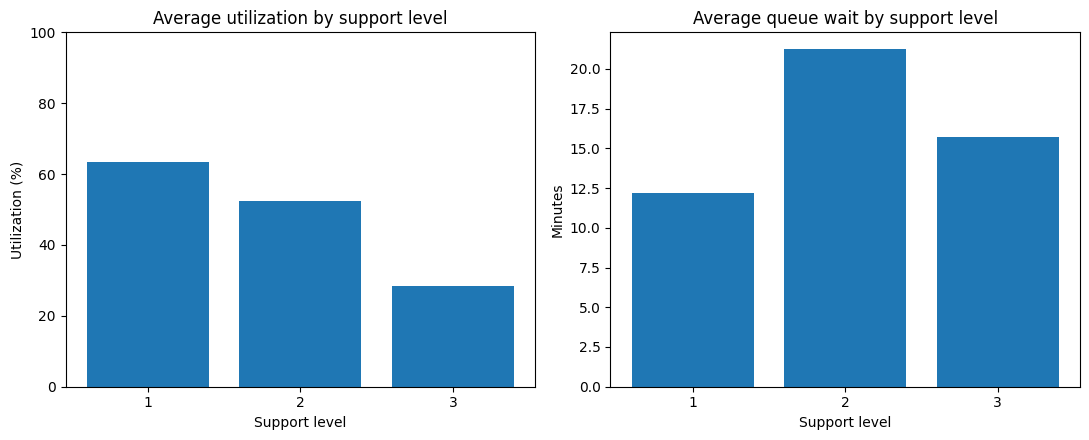

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(
    station_summary["Level"].astype(str),
    station_summary["AverageUtilizationPercent"],
)
axes[0].set_title("Average utilization by support level")
axes[0].set_xlabel("Support level")
axes[0].set_ylabel("Utilization (%)")
axes[0].set_ylim(0, 100)

axes[1].bar(
    station_summary["Level"].astype(str),
    station_summary["AverageWaitMinutes"],
)
axes[1].set_title("Average queue wait by support level")
axes[1].set_xlabel("Support level")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

## 8. Export report tables

In [36]:
ticket_results.to_csv("simulated_ticket_results.csv", index=False)
event_log.to_csv("ticket_event_log.csv", index=False)
technician_summary.to_csv("technician_utilization.csv", index=False)
station_summary.to_csv("station_summary.csv", index=False)
overall_summary.to_csv("overall_summary.csv", index=False)

print("Output files saved.")

Output files saved.


## Assumptions to state in the report

- Ticket arrivals follow a homogeneous Poisson process during staffed business time.
- The assumed arrival rate is 15 tickets per 8-hour workday.
- Each simulated ticket samples one complete historical ticket row with replacement.
- The sampled `Closed_Level` determines routing.
- The sampled level-minute fields determine service time.
- Queues follow FIFO order.
- Technicians at a given level have equal capability.
- Service times of different simulated tickets are independent.
- The simulation clock contains staffed business minutes only; nights and weekends are omitted.
- Tickets still unfinished when the run ends are reported as ending backlog.